## Example 5: Shor's Algorithm

### Purpose

This example uses TinyQsim to demonstrate the principle of Shor's Integer Factoring Algorithm. It makes use of the Quantum Fourier Transform (QFT) and Quantum Phase Estimation (QPE) algorithms that were explored in previous examples, so it would be useful to become familiar with those examples first.

### Introduction

Factoring large composite numbers is an interesting mathematical problem in its own right, but it is has particular practical implications for the widely-used RSA encryption system. RSA relies for its security on the fact that it is easy to multiply two large prime numbers but very difficult to find the factors if you are just given their product.

In 1994, Peter Shor published a quantum algorithm, now known as Shor's algorithm, that can theoretically factor large composite numbers exponentially faster than a classical computer. Daniel Simon had previously shown the possibility of exponential speedup on a contrived problem, but Shor's algorithm was the first to offer the promise of exponential speedup on a real-world problem. To have any practical advantage over classical factoring methods, Shor's algorithm would need to be run on a quantum computer with thousands of logical (error free) qubits, which is still some way in the future.

Shor's algorithm is a hybrid algorithm that combines both classical and quantum computation. The top-level routine is classical and calls a quantum order-finding subroutine that runs on a quantum computer.

We will start by looking at how the factoring process works and initially demonstrate it using a classical implementation of the order-finding part. We will then implement a simulation of quantum order-finding using TinyQsim and demonstate the factorisation of some small composite numbers using the quantum algorithm.

### Imports and Definitions

The example will make use of the following Python imports and definitions. These include the Quantum Fourier Transform (QFT) and Quantum Phase Estimation (QPE) code from previous example notebooks.

In [1]:
from tinyqsim.qcircuit import QCircuit
from tinyqsim.utils import bits_to_int
from examples_lib import iqft, build_qpe_circuit, continued_fraction, convergents, build_qpe_circuit
from math import gcd, log2, ceil
from fractions import Fraction
from functools import partial
import numpy as np
import random

In [2]:
MAX_TRIES = 10  # Give up after 10 attempts

In [3]:
def format_bits(bitlist, nbits=0):
    """Format a list of bits (0 or 1) as a string, optionally padded with zeros to nbits."""
    return ''.join([str(i) for i in bitlist]).zfill(nbits)

### The Top-Level Algorithm

The algorithm is based on number theory and makes use of modular arithmetic as well as Euclid's algorithm for efficiently finding the Greatest Common Divisor (GCD) of two integers.

The aim is to factor a composite number $N$ into its factors $p_1$ and $p_2$:

$$
N=p_1\ p_2
$$

We will assume that these factors are odd primes. If $N$ is even, then $2$ is trivially a factor. If the values are not prime, we can recursively call the factorization routine, using a classical primality test to decide when to stop recursing.

We start by choosing a random integer $a$ such that $1<a<N$.

If $\gcd(a,N)\ne 1$ then the GCD is a factor and we can stop.

Otherwise, we find the *multiplicative order* of $a$ modulo $N$. This is defined as the smallest positive integer $r$ such that:

$$
a^r\equiv 1\pmod{N}
$$

where $a$ is an integer coprime to $N$:

$$
\gcd(a, N)=1
$$

Finding the order is the part of the algorithm that can make use of a quantum processor to give an exponential speed improvement.

If $r$ is odd we restart the algorithm with a new random value of $a$. If $r$ is even, then $\frac{r}{2}$ is an integer and we have found a square root of $1$ modulo $N$:

$$
(a^{r/2})^2 \equiv 1\pmod{N}
$$

By the difference of squares:

$$
(a^{r/2})^2 - 1^2 \equiv 0\pmod{N}
$$

$$
(a^{r/2}-1)(a^{r/2}+1)\equiv 0\pmod{N}
$$

Hence:

$$
N\ |\ (a^{r/2}-1)(a^{r/2}+1)
$$

If $N\nmid (a^{r/2}\pm 1)$ then the following must be factors of $N$ and we have a solution:

$$
\qquad\gcd(a^{r/2}+1, N)\quad\text{ and }\quad\gcd(a^{r/2}-1, N)
$$

We require that neither of the terms $(a^{r/2}+1)$ and $(a^{r/2}-1)$ is zero. The latter can't be zero because it would imply that $r/2$ was the order of $a$ modulo $N$; but it is smaller than $r$ which is defined as the smallest positive integer $r$ such that $a^r\equiv 1\pmod{N}$, which would lead to a contradiction. To guard against the first one being zero, we restart the algorithm with a new random $a$ if:

$$
\quad a^{r/2}\equiv -1\pmod{N}
$$

It can be seen from the above that the algorithm is probabilistic in nature and may fail at at several points if certain conditions are not met. In these cases, the algorithm is restarted with a new random value of $a$. The condition that $r$ must be even has a probability of about 50%. The conditional probability that $a^{r/2}\not\equiv -1\pmod{N}$, given that $r$ is even, is at least 50%. From this simplistic analysis, the probability of success for a particular initial guess is $\approx$25%, which implies that about 4 tries are needed on average.

When the order-finding is run on a quantum processor, the speed is exponentially greater than factoring on a classical computer. Even if a few runs are needed because of the restarts, the overall speedup is still exponentially better.

### Simple Numerical Example

To demonstrate how the algorithm works, we will factor $N=21$.

Let us assume $a=2$ as the random starting value, chosen so that $1<a<N$.

First, calculate $\gcd(2,21)=1$

As the GCD is 1, it follows that 2 and 21 are coprime, so there isn't a trivial factor and we can proceed with the "difference of squares" approach.

Next, we need to find the order $r$, which is the smallest positive integer such that $2^r\equiv 1\pmod{21}$. To do this classically, we could try succesive integers for 'r':

$$
\begin{align*}
2^0&\equiv 1&\pmod{21}&\quad\text{(ignore)}\\
2^1&\equiv 2&\pmod{21}\\
2^2&\equiv 4&\pmod{21}\\
2^3&\equiv 8&\pmod{21}\\
2^4&\equiv 16&\pmod{21}\\
2^5&\equiv 11&\pmod{21}\\
2^6&\equiv 1&\pmod{21}\\
\end{align*}
$$

Hence the order $r=6$. The pattern repeats with a cycle length of 6, with the first cycle starting at $r=0$.

Since $r$ is even, we can proceed as follows, using the difference of squares:

$$
2^6-1\equiv 0 \pmod{21}
$$

$$
(2^\frac{6}{2}+1)(2^\frac{6}{2}-1)\equiv 0\pmod{21}
$$

$$
9\times 7 \equiv 0\pmod{21}
$$

$21$ doesn't divide $7$ or $9$, so the GCDs of $7$ and $9$ with $21$ must divide $21$.

The required factors of 21 are therefore:

$$
\gcd(9,21)=3\quad\text{ and }\quad\gcd(7,21)=7
$$

### Classical Order Finding

The top-level algorithm described above can be coded in Python as follows. To demonstrate that this works as intended, a simple classical implemention of the order-finding routine will be used initially.

In [4]:
# A non-quantum order-finding routine
def order_classical(a, N):
    for r in range(1,N):
        if pow(a,r,N) == 1:
            return r
    raise ValueError(f'Failed to find order of {a} modulo {N}')

In [5]:
def factorize_classical(N: int):
    for _ in range(MAX_TRIES):
        a = random.randint(2, N-1)
        g = gcd(a, N)
        if g > 1:
            return g, N//g  # Trivial factors if a & N are not coprime
        r = order_classical(a, N)
        if (r % 2 == 0) and (a ** (r//2)) % N != N-1:
            return gcd(a ** (r//2) + 1, N), gcd(a ** (r//2) - 1, N)
    return None

The 'for' loop limits the number of restarts to avoid an infinite loop if the factorize function is called with a prime number.

To demonstrate that this top-level routine works as intended, we can try factoring a few numbers:

In [6]:
print(factorize_classical(21))
print(factorize_classical(119))
print(factorize_classical(247))

(7, 3)
(17, 7)
(13, 19)


### Quantum Order Finding

Shor's algorithm achieves its performance gain on a quantum computer by using a quantum implementation of order-finding. This actually has both quantum and classical parts:

- A quantum circuit that performs Quantum Phase Estimation (QPE)
- A classical algorithm that extracts the order $r$ from the phase

We need to find the multiplicative order of $a$ modulo $N$, which is defined as the smallest integer such that:

$$
a^r\equiv 1\pmod N
$$

where $a$ is coprime to $N$.

Quantum order finding works by defining a unitary $U$ such that:

$$
U: \ket{x}\mapsto \ket{ax\bmod N}
$$



The QPE returns an approximation to an eigenvalue of $U$, when the input of the target register is the corresponding eigenstate.

If $U_{a,N}\ket{x} = \ket{ax \bmod N}$, then it satisfies $U^r_{a,N}=I$ when $r$ is the order.

Hence, its eigenvalues will be $e^{2\pi\frac{k}{r}}$ for $k=0,\dots,r-1$.

Applying $U$ to the eigenstate $k$ times multiplies the phase $\phi_s$ by $k$:

$$
U^k\ket{u_e}=e^{2\pi ik\phi_s}\ket{u_e}
$$

$$
U^k: \ket{x}\mapsto \ket{a^kx\bmod N}
$$

where $\ket{u_e}$ is the eigenvector of $U$ for which we want to find the eigenvalue.

Using Quantum Phase Estimation (QPE) with $m$ qubits for the control register, we will measure some value $x$, such that $\frac{x}{2^m}$ is an approximation to $\frac{k}{r}$:

$$
\frac{x}{2^m}\approx\frac{k}{r}
$$

We need to deduce the order $r$ by finding the exact rational $\frac{k}{r}$ from the approximation $\frac{x}{2^m}$.

This can be done by computing the sequence of continued-fraction convergents and checking each one to see whether its denominator is the order $r$ of $a$ modulo $N$. This should be done in order of increasing candidate $r$, as the order is defined as the *smallest* such value.

$$
a^r\equiv 1\pmod{N}
$$

The approximation error is:

$$
\left|\frac{x}{2^m}-\frac{k}{r}\right|
$$

There is a theorem by Legendre that states that if a rational number $\frac{p}{q}$ is a sufficently good approximation of a real number $\alpha$, such that:

$$
\left|\alpha-\frac{p}{q}\right| < \frac{1}{2q^2}
$$

then $\frac{p}{q}$ must be one of the convergents of the continued fraction of $\alpha$.

Rather than test each convergent denominator to see whether it is the order 'r' of $a$ mod $N$, it is faster to only test ones that satisfy the approximation error condition:

$$
\left|\frac{x}{2^m}-\frac{k}{r}\right| < \frac{1}{2r^2}
$$

The procedure may still sometimes fail to find the order because the convergents are *reduced fractions* in their lowest terms. The actual order may therefore be a multiple of the convergent denominator. The simplest solution is to restart the algorithm with a new random value $a$, as is done for other failure conditions. Another approach is to try small multiples of the candidate order.

To keep this example simple, we will just test the denominator of each convergent to see whether it is the order 'r' of $a$ mod $N$ and accept that there may be a few more retries.

### Implementing the Unitary

The unitary operator $U$ is specific to given values of $a$ and $N$ and consequently needs to be constructed for each run of the circuit. There are several ways to build such an operation out of gates, but they are quite complicated. Since the purpose of this notebook is just to demonstrate the principle of Shor's algorithm, we will implement the unitary as a single $2^K\times 2^K$ unitary matrix, where $K$ is the number of qubits necessary for a binary represententation of the number to be factored. Modular exponentiation can be viewed as a permutation operation, so the matrix can be constructed by starting with an identity matrix and permuting the columns, as shown in the following simple implementation.

In [7]:
def modexp_unitary(a, N, k, nq):
    """Build unitary gate for modular exponentiation: a^k mod N.
      This is a slow but simple implementation as a matrix.
    """
    assert gcd(a, N) == 1  # Pre-condition: 'a' is coprime with N
    m = np.eye(2**nq, dtype=int)
    m[[(a ** k * i) % N for i in range(N)]] = m[range(N)]
    return m

### Quantum Phase Estimation

The following Python function constructs and runs the quantum circuit for performing Quantum Phase Estimation using the modular exponentiation unitary. See the previous notebook on Quantum Phase Estimation for more background and the definition of the function 'build_qpe_circuit'.

In [8]:
def run_quantum_circuit(a, N, m=None):
    """Build and run the quantum phase estimation circuit."""

    # Calculate register sizes
    t = int.bit_length(N)  # Size of state register (to hold N)
    if not m:
        m = ceil(2 * log2(N)) + 1 # Size of control register
    print(f'N={N}, m={m}, t={t}')

    # Create the QPE circuit
    qc = build_qpe_circuit(partial(modexp_unitary, a, N), m, t)

    # Measure the state
    qc.barrier('3')
    bits = qc.measure(*range(m))
    return qc, bits

We can now build the quantum circuit for specific values of $a$ and $N$.

The following diagram shows the general form of the circuit. The default value $m$ has been overidden to reduce the number of control qubits from 8 to 4, to keep the diagram simple.

The circuit is the same as the example in the QPE notebook except that it is using the modular exponentiation unitary and measurements are performed on the output of the control register.

N=15, m=4, t=4


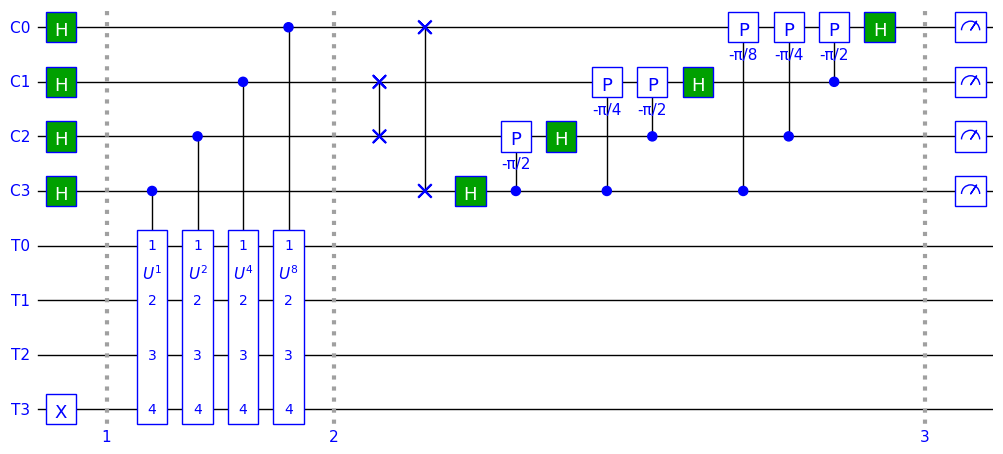

In [9]:
qc, bits = run_quantum_circuit(a=11, N=15, m=4)
qc.draw()

The cicuit is split into four parts by the barrier symbols:

- Initialization
- Phase kickback
- Inverse QFT
- Measurement of result


The barrier symbols are labelled 1,2,... so that the state at these points can be referred to as $\ket{\psi_1},\ket{\psi_2}$, etc.

The qubits are split into two registers, C and T. Register C is the control register, with $m$ qubits, and register T is the target register, with $t$ qubits, that is initialized with the eigenvector. Register T requires enough qubits to hold the binary representation of the number $N$ that is to be factored:

$$
t=\lceil\log_2 N\rceil
$$

Register C normally requires more qubits than register T to give the required phase resolution. The following value is commonly used:

$$
m = \lceil 2\log_2 N\rceil + 1
$$

In the circuit above, a smaller value has been used to make the diagram easier to understand.

The control register is placed in the equal superposition state by the Hadamard gates. The target register is placed in the state $\ket{0001}$ which is an eigenvector of the unitary $U$.

$$
\ket{\psi_1}=\frac{1}{\sqrt{M}}\sum_{k=0}^{M-1}\ket{k}\ket{u_e}
$$

where $M=2^\text{m}$

Applying the unitary operators gives:

$$
\begin{align*}
\ket{\psi_2}&={\small\frac{1}{\sqrt{M}}}\sum_{k=0}^{M-1}\ket{k}U^k\ket{u_e}\\
&={\small\frac{1}{\sqrt{M}}}\sum_{k=0}^{M-1}e^{2\pi ik\phi_s}\ket{k}\ket{u_e}
\end{align*}
$$

The Quantum Fourier Transform (QFT) is defined as:
$$
QFT: \ket{x}\mapsto\frac{1}{\sqrt{M}}\sum_{k=0}^{M-1}{\large e^\frac{2\pi ixk}{M}}\ \ket{k}
$$

So applying the inverse QFT to register C results in:

$$
\ket{\psi_3}=\ket{x}\ket{\lambda}
$$

where the phase $\theta$ is approximated by the binary fraction $\large\frac{x}{2^m}$.

### Computing the Order

The next step is to find the multiplicative order $r$ from the estimated phase.

The result of the quantum phase estimation is the phase expressed as a binary fraction $\large\frac{x}{2^m}$ approximated to '$m$ bits.

This is an approximation to the true phase:

$$
\phi = \frac{k}{r} \approx \frac{x}{M}
$$

where $k=0,1,\dots,r-1$

We need to deduce the order $r$ by finding the exact rational $\frac{k}{r}$ from the approximation $\frac{x}{M}$.

This can be done by computing the sequence of continued-fraction convergents. These are a sequence of progressively better approximations to a fraction. For example, the first few convergents for $\pi$ are $\frac{22}{7}, \frac{333}{106}, \frac{355}{113},\dots$. 

In our case, we have rational fraction, so the sequence is finite. We just need to check each convergent to see whether its denominator is the order of $a$ modulo $N$:

$$
a^q\equiv 1\pmod{N}
$$

The following function is used to compute the sequence of convergents from the phase returned by the Quantum Phase Estimation circuit.

In [10]:
def build_convergents(x):
    """Build convergents of continued fraction."""
    f = Fraction(x)
    fraction = continued_fraction(f)
    print(f'continued_frac={fraction}')
    return list(convergents(fraction))

The order is then found by checking each convergent to find the first one whose denominator $q$ satisfies:

$$
a^q \equiv 1 \pmod{N}
$$

This may fail as the convergents are reduced fractions, in which case the algorithm is restarted with a new value of $a$.

In [11]:
def order_from_measured_bits(bits, a, N):

    """Convert measurement result to phase."""
    m = len(bits)
    x = bits_to_int(bits)
    M = 2 ** m

    # Find convergents
    f = Fraction(x, M)
    convergents = build_convergents(f)
    print('Convergents:', [f'{p}/{q}' for p,q in convergents])

    for p,q in convergents:
        if q > N:
            return None
        if q == 1:
            continue

        # Check whether convergent is a good enough approximation
        ok = abs(x/M - p/q) <= 1/(2 * 2**m)

        if ok:
            for i in range(1,5):
                print(f'a={a}, q={q}, i={i}, {pow(a, q*i, N)}')
                if pow(a, q*i, N) == 1:
                    return q*i
    return None

Putting the above functions together, we can define the quantum order-finding routine. This involves generating and running the quantum circuit and then extracting the order from the measured phase.

In [12]:
def order_quantum(a, N):
    """Quantum order-finding function."""

    # Run the quantum circuit
    qc, bits = run_quantum_circuit(a, N)
    bits = qc.results().values()  # FIXME: Assumes dict is ordered
    print(f'bits: {format_bits(bits, len(bits))} = {bits_to_int(bits)}')

    # Convert measurement result to phase
    return order_from_measured_bits(bits, a, N)

Finally, we can put everything together into a top-level factoring function:

In [13]:
def shor_factorize(N, n_tries=MAX_TRIES):
    """Factor N using Shor's Algorithm."""
    
    # Attempt to find the order r of a^x mod N.
    for trial in range(1, n_tries + 1):
        print(f'\nTrial # {trial}')
        a = random.randint(2, N - 1)
        print(f'Random a={a}')

        g = gcd(a, N)
        if g > 1:
            print('Success: a and N are not coprime')
            return g, N // g  # Trivial factors if a & N are not coprime
        
        r = order_quantum(a, N)
        print(f'Order r (classical) = {order_classical(a, N)}') # For comparison
        print(f'Order r (quantum) = {r}')
        
        if not r:
            print('Retry as convergent not found')
            continue

        if r % 2 != 0:
            print('Retry as r is odd')
            continue

        if (a ** (r // 2)) % N == N - 1:
            print(f'Retry as a**r//2 mod N = N-1')
            continue

        print(f'Success with difference of squares')
        return gcd(a ** (r // 2) + 1, N), gcd(a ** (r // 2) - 1, N)

    print(f'Failed to find a solution after {n_tries} attempts')
    return None

### Demonstration

The following demonstration shows $119$ being factored using the quantum algorithm. 

In [14]:
shor_factorize(119)


Trial # 1
Random a=101
N=119, m=15, t=7
bits: 000000000000000 = 0
Fraction = 0/1
continued_frac=[0]
Convergents: ['0/1']
Order r (classical) = 6
Order r (quantum) = None
Retry as convergent not found

Trial # 2
Random a=23
N=119, m=15, t=7
bits: 000010101010101 = 1365
Fraction = 1365/32768
continued_frac=[0, 24, 170, 1, 1, 1, 2]
Convergents: ['0/1', '1/24', '170/4081', '171/4105', '341/8186', '512/12291', '1365/32768']
a=23, q=24, i=1, 50
a=23, q=24, i=2, 1
Order r (classical) = 48
Order r (quantum) = 48
Success with difference of squares


(17, 7)

You can try factoring other numbers but the algorithm will become very slow for larger values of $N$. When it is run on a real quantum computer, Shor's algorithm can potentially give an exponential speed-up over a classical computer. However, when simulated on a classical computer, it is very much slower than a classical factorization algorithm.

### Example Output

Because of the probabilistic nature of the algorithm, there may be a number of retries and different paths to the solution. If the random variable $a$ is not coprime with $N$, it may even return the result without using the quantum algorithm.

The following snapshots show some example outputs that may occur when factoring 119.

#### Example A

This is the nominal situation in which the algorithm finds a convergent whose denominator is the required order.

$$
a^r \bmod{N} = 29^{16} \bmod{119} = 1
$$

#### Example B

In this example, the convergent $1/12$ satisfies the appproximation criterion, but 12 is not the order because the convergent is a reduced fraction.

$$
87^{12} \bmod{119} = 50
$$

Small multiples of 12 are then tried, with a multiple of 2 giving the required order 24:

$$
87^{2\times 12} \bmod{119} = 1
$$

#### Example C

The first attempt fails because the value of $r$ does not satisfy the requirement that $a^\frac{r}{2} \not\equiv -1 \pmod{N}$. 

$$
118^{\frac{2}{2}} \equiv -1 \pmod{119}
$$

In this particular example, the cause of the failure was that the measured phase was zero. This value has a non-zero probability in the QPE, which leads to a failure.

The algorithm starts again with a different random value $a=56$ which happens not to be coprime to $N$, so one factor is $\gcd(119, 56)=7$ and the other is $119/7=17$.